In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('RecipeDB_general.csv', low_memory=False)
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")


Dataset loaded: 118083 rows, 24 columns


In [2]:
# Display first few rows
print("\n=== First 5 Rows ===")
print(df.head())

# Data types
print("\n=== Data Types ===")
print(df.dtypes)

# Basic statistics
print("\n=== Numerical Summary Statistics ===")
print(df.describe())

# Dataset info
print("\n=== Dataset Info ===")
df.info()



=== First 5 Rows ===
   Recipe_id  Calories cook_time prep_time servings  \
0       2610     196.0        30        15        4   
1       2611      80.0        35        10        4   
2       2612     339.0       120        15        4   
3       2613     409.0        15        15        3   
4       2614      45.0         5        20       24   

                        Recipe_title total_time  \
0               Egyptian Lentil Soup         45   
1  Egyptian Green Beans with Carrots         45   
2                     Egyptian Bamia        135   
3        Magpie's Easy Falafel Cakes         60   
4                             Dukkah         25   

                                                 url          Region  \
0  http://allrecipes.com/recipe/222661/egyptian-l...  Middle Eastern   
1  http://allrecipes.com/recipe/233456/egyptian-g...  Middle Eastern   
2  http://allrecipes.com/recipe/227986/egyptian-b...  Middle Eastern   
3  http://allrecipes.com/recipe/143113/magpies-ea...


=== Missing Values Summary ===
                                                          Column  \
Utensils                                                Utensils   
Carbohydrate, by difference (g)  Carbohydrate, by difference (g)   
Energy (kcal)                                      Energy (kcal)   
Protein (g)                                          Protein (g)   
Total lipid (fat) (g)                      Total lipid (fat) (g)   
Processes                                              Processes   

                                 Missing_Count  Missing_Percentage  
Utensils                                 14588               12.35  
Carbohydrate, by difference (g)           1044                0.88  
Energy (kcal)                             1044                0.88  
Protein (g)                               1044                0.88  
Total lipid (fat) (g)                     1044                0.88  
Processes                                  230                0.19  


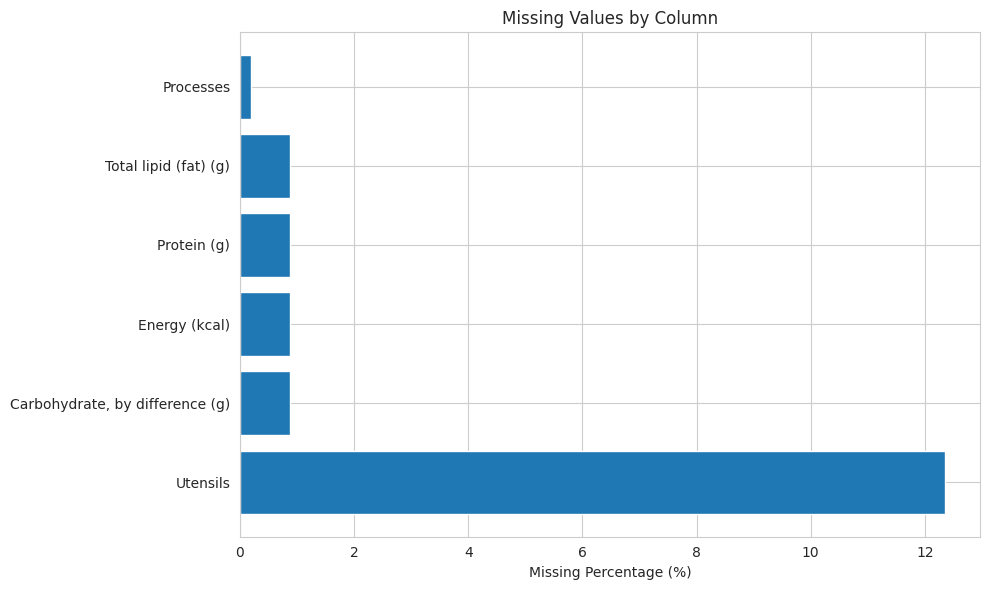

In [ ]:
# Missing values visualization
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("\n=== Missing Values Summary ===")
print(missing_data)

# Visualize missing values
plt.figure(figsize=(10, 6))
plt.barh(missing_data['Column'], missing_data['Missing_Percentage'])
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Values by Column')
plt.tight_layout()
plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')
plt.show()



=== Nutritional Statistics ===
            Calories  Carbohydrate, by difference (g)  Energy (kcal)  \
count  117039.000000                    117039.000000   1.170390e+05   
mean      475.213591                       835.972820   9.697008e+03   
std      2177.462088                      6758.136886   6.122659e+04   
min         0.000000                         0.000000   0.000000e+00   
25%       189.400000                        22.943950   5.530741e+02   
50%       340.600000                        64.313300   1.249370e+03   
75%       549.400000                       199.952450   2.439779e+03   
max    612854.600000                    252062.680000   3.440457e+06   

         Protein (g)  Total lipid (fat) (g)  
count  117039.000000          117039.000000  
mean      509.474261             488.816511  
std      4077.491455            4345.346591  
min         0.000000               0.000000  
25%        13.681100              17.729300  
50%        49.506900              54.503500

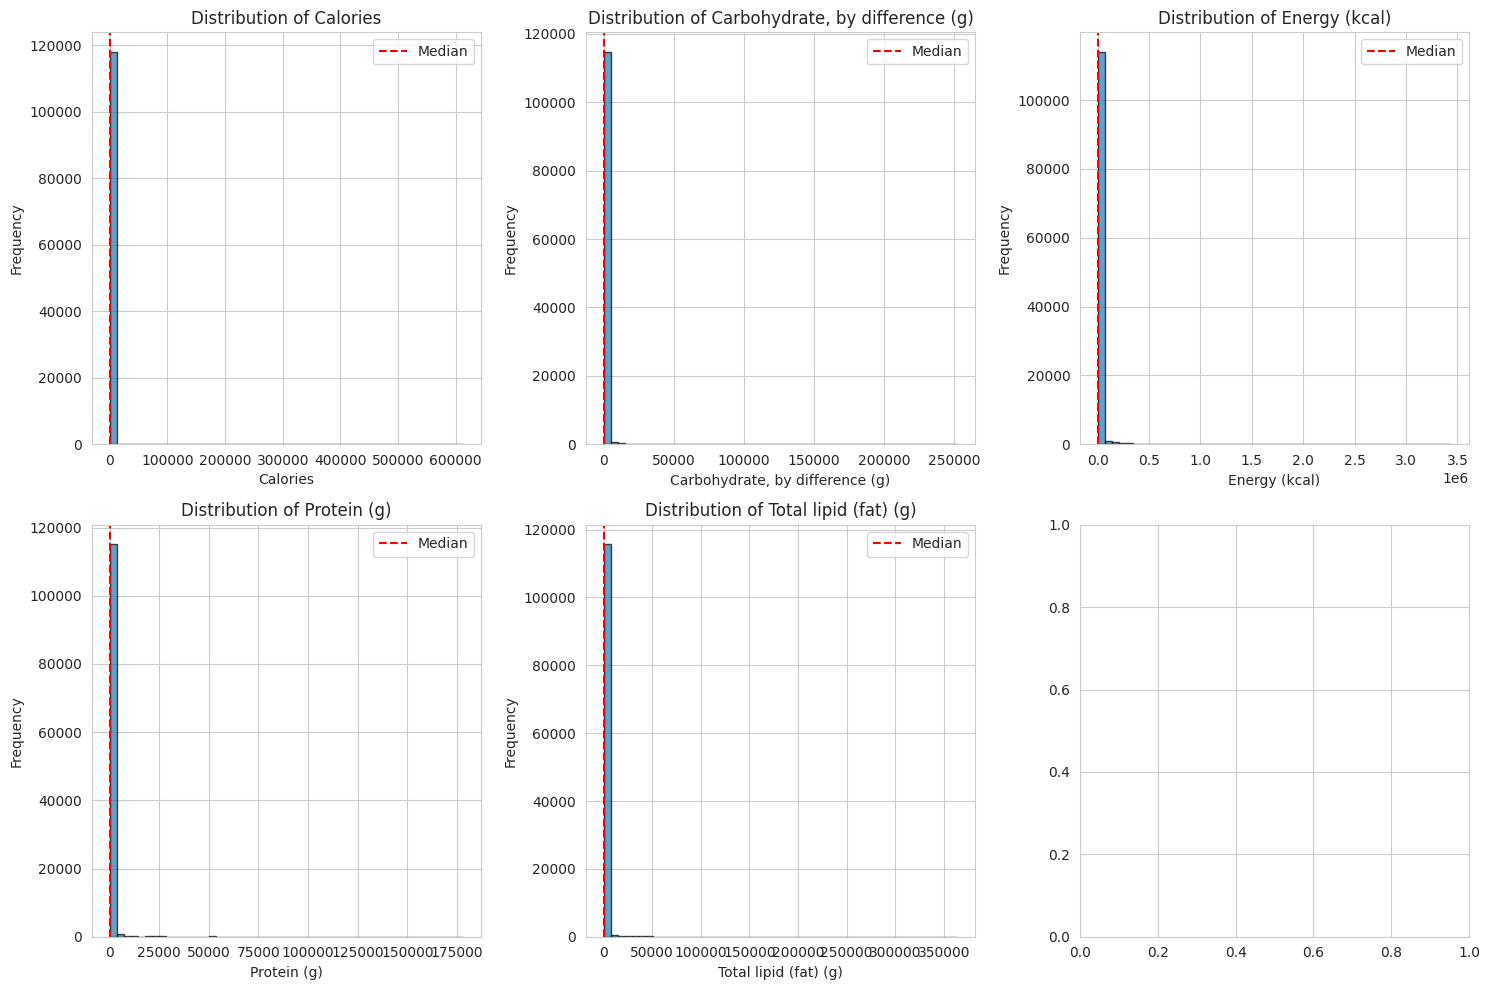

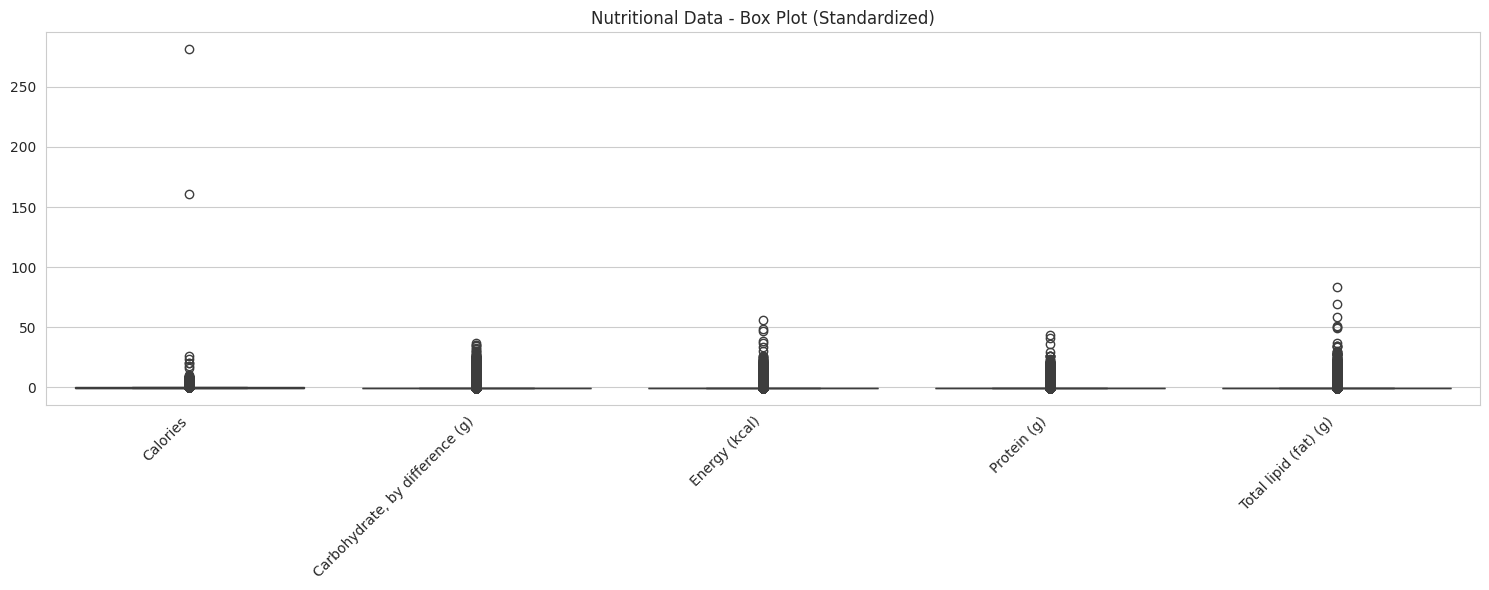

In [3]:
# Nutritional columns
nutrient_cols = ['Calories', 'Carbohydrate, by difference (g)',
                 'Energy (kcal)', 'Protein (g)', 'Total lipid (fat) (g)']

# Remove rows with missing nutrients for analysis
df_nutrients = df[nutrient_cols].dropna()

print("\n=== Nutritional Statistics ===")
print(df_nutrients.describe())

# Distribution plots for nutrients
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(nutrient_cols):
    axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].axvline(df[col].median(), color='red', linestyle='--', label='Median')
    axes[idx].legend()

plt.tight_layout()
plt.savefig('nutrient_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Box plots for outlier detection
plt.figure(figsize=(15, 6))
df_nutrients_scaled = (df_nutrients - df_nutrients.mean()) / df_nutrients.std()
sns.boxplot(data=df_nutrients_scaled)
plt.title('Nutritional Data - Box Plot (Standardized)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('nutrient_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()



=== Nutrient Correlation Matrix ===
                                 Calories  Carbohydrate, by difference (g)  \
Calories                         1.000000                         0.015836   
Carbohydrate, by difference (g)  0.015836                         1.000000   
Energy (kcal)                    0.019809                         0.617859   
Protein (g)                      0.018822                         0.225234   
Total lipid (fat) (g)            0.012315                         0.191234   

                                 Energy (kcal)  Protein (g)  \
Calories                              0.019809     0.018822   
Carbohydrate, by difference (g)       0.617859     0.225234   
Energy (kcal)                         1.000000     0.687441   
Protein (g)                           0.687441     1.000000   
Total lipid (fat) (g)                 0.853234     0.493358   

                                 Total lipid (fat) (g)  
Calories                                      0.012315  
C

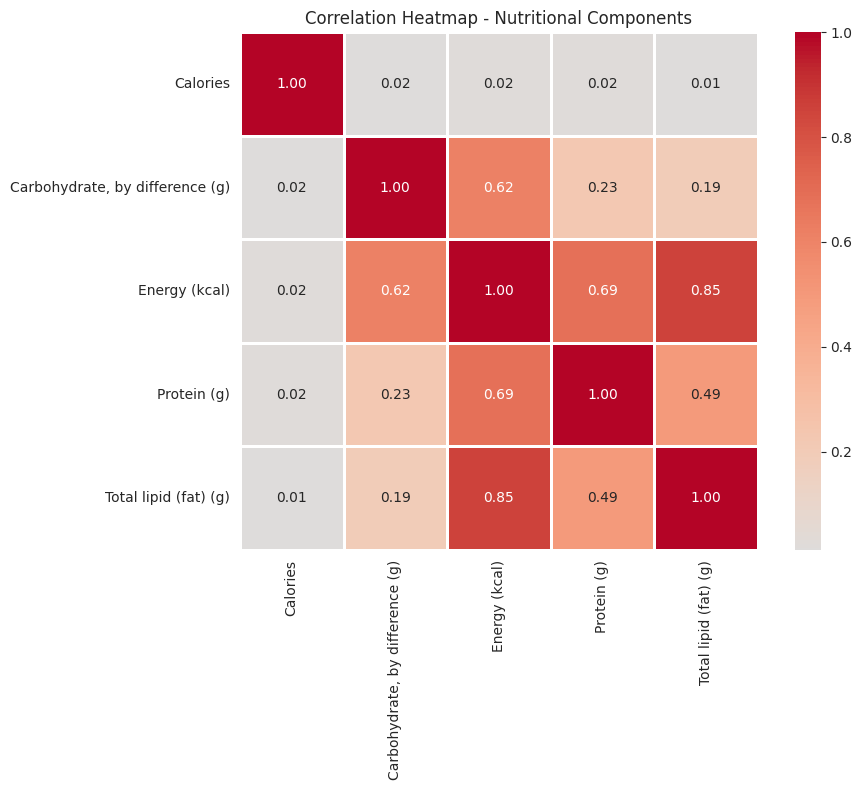

In [4]:
# Correlation matrix
correlation_matrix = df_nutrients.corr()

print("\n=== Nutrient Correlation Matrix ===")
print(correlation_matrix)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Heatmap - Nutritional Components')
plt.tight_layout()
plt.savefig('nutrient_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()



=== Regional Distribution ===
Region
Italian                   16574
Mexican                   14447
South American             7171
Canadian                   6694
Indian Subcontinent        6463
French                     6375
Chinese and Mongolian      5888
Australian                 5819
US                         5025
UK                         4396
Deutschland                4321
Greek                      4181
Middle Eastern             3905
Caribbean                  3023
Spanish and Portuguese     2843
Scandinavian               2811
Rest Africa                2739
Thai                       2603
Irish                      2529
Eastern European           2503
Japanese                   2040
Southeast Asian            1940
Northern Africa            1610
Belgian                    1060
Korean                      668
Central American            455
Name: count, dtype: int64


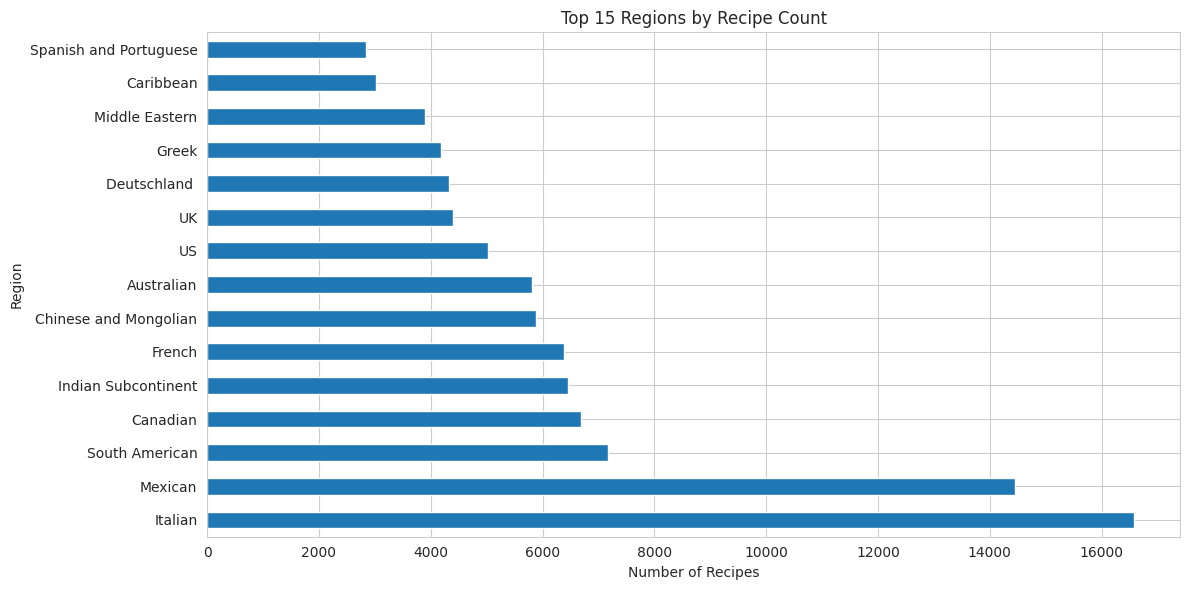


=== Continent Distribution ===
Continent
European          47593
Latin American    25096
Asian             23182
North American    11719
Australasian       5819
African            4674
Name: count, dtype: int64


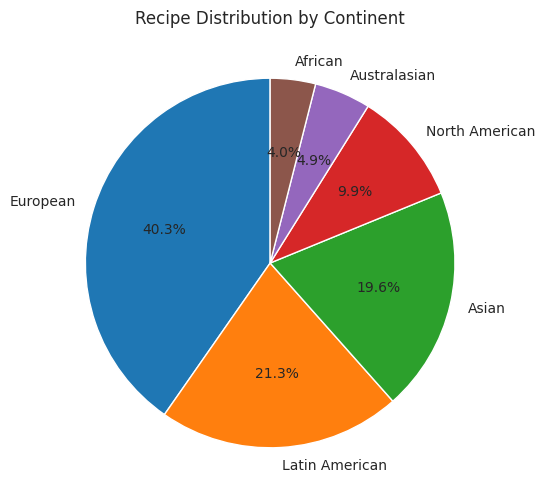

In [5]:
# Region distribution
print("\n=== Regional Distribution ===")
region_counts = df['Region'].value_counts()
print(region_counts)

# Top 15 regions
plt.figure(figsize=(12, 6))
region_counts.head(15).plot(kind='barh')
plt.xlabel('Number of Recipes')
plt.title('Top 15 Regions by Recipe Count')
plt.tight_layout()
plt.savefig('region_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Continent distribution
print("\n=== Continent Distribution ===")
continent_counts = df['Continent'].value_counts()
print(continent_counts)

plt.figure(figsize=(10, 6))
plt.pie(continent_counts, labels=continent_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Recipe Distribution by Continent')
plt.savefig('continent_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



=== Cooking Time Statistics ===
Cook Time - Mean: 5.73 min
Prep Time - Mean: 2.49 min
Total Time - Mean: 149.88 min


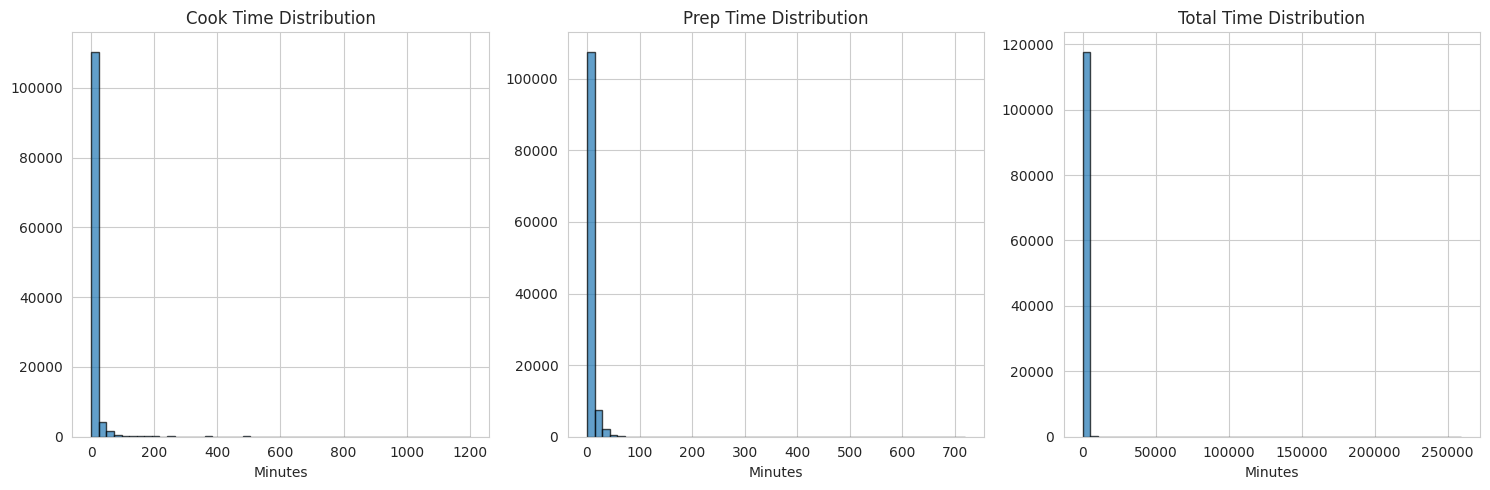

In [6]:
# Convert time columns to numeric (handling mixed types)
def convert_time(time_val):
    try:
        return float(time_val)
    except:
        return np.nan

df['cook_time_numeric'] = df['cook_time'].apply(convert_time)
df['prep_time_numeric'] = df['prep_time'].apply(convert_time)
df['total_time_numeric'] = df['total_time'].apply(convert_time)

print("\n=== Cooking Time Statistics ===")
print(f"Cook Time - Mean: {df['cook_time_numeric'].mean():.2f} min")
print(f"Prep Time - Mean: {df['prep_time_numeric'].mean():.2f} min")
print(f"Total Time - Mean: {df['total_time_numeric'].mean():.2f} min")

# Time distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df['cook_time_numeric'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Cook Time Distribution')
axes[0].set_xlabel('Minutes')

axes[1].hist(df['prep_time_numeric'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Prep Time Distribution')
axes[1].set_xlabel('Minutes')

axes[2].hist(df['total_time_numeric'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Total Time Distribution')
axes[2].set_xlabel('Minutes')

plt.tight_layout()
plt.savefig('cooking_time_distributions.png', dpi=300, bbox_inches='tight')
plt.show()



=== Diet Category Distribution ===
vegan: 10643 recipes (9.01%)
pescetarian: 13184 recipes (11.17%)
ovo_vegetarian: 3 recipes (0.00%)
lacto_vegetarian: 9165 recipes (7.76%)
ovo_lacto_vegetarian: 3 recipes (0.00%)


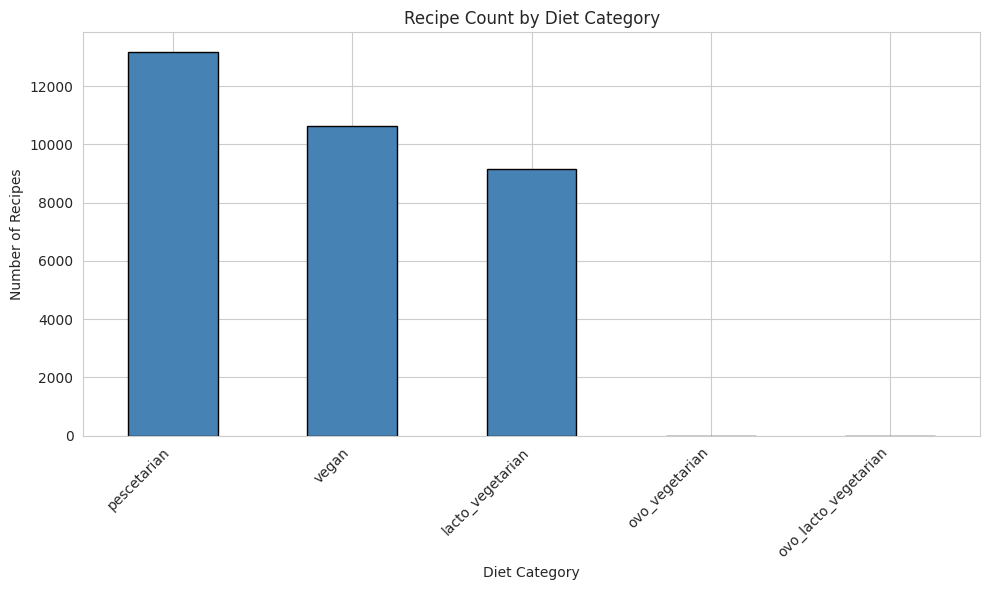

In [7]:
# Diet categories
diet_cols = ['vegan', 'pescetarian', 'ovo_vegetarian', 'lacto_vegetarian', 'ovo_lacto_vegetarian']

print("\n=== Diet Category Distribution ===")
for col in diet_cols:
    count = df[col].sum()
    percentage = (count / len(df) * 100)
    print(f"{col}: {int(count)} recipes ({percentage:.2f}%)")

# Diet category counts
diet_counts = df[diet_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
diet_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Diet Category')
plt.ylabel('Number of Recipes')
plt.title('Recipe Count by Diet Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('diet_category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



=== Cooking Processes Analysis ===
Processes
|    2648658
e     872996
r     640025
a     604205
o     539832
d     494624
s     458159
i     440907
t     438317
c     336440
l     246117
m     240369
      235706
p     225640
h     189975
n     187300
k     178147
v     153110
b     134487
u      93062
Name: count, dtype: int64


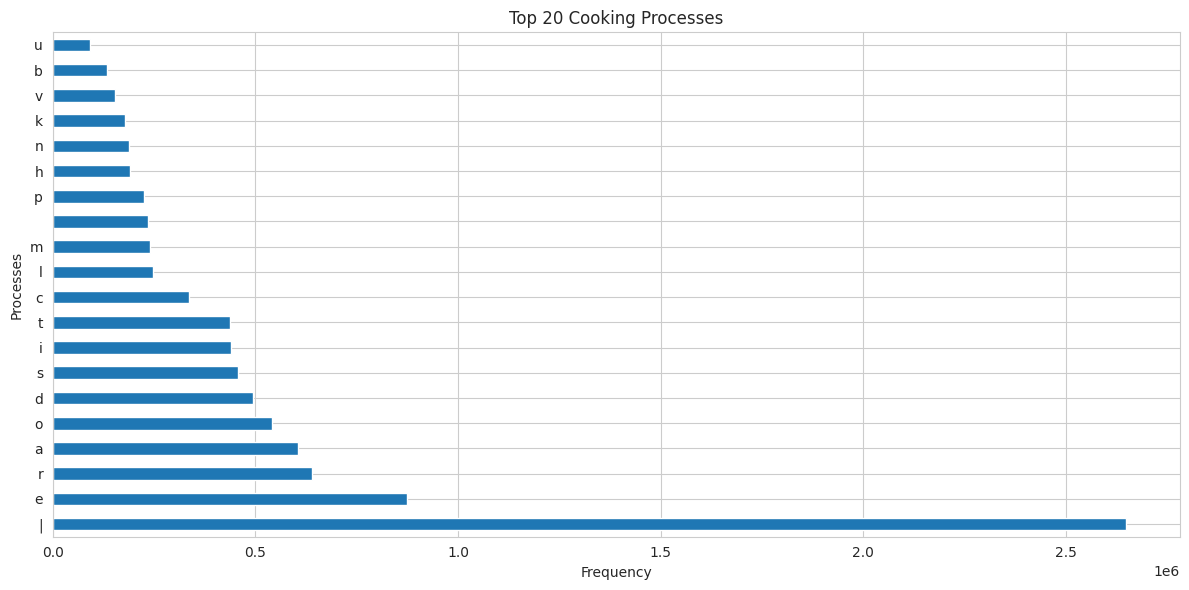


=== Utensils Analysis ===
Utensils
|    527842
     206990
o    197150
e    170478
n    166773
l    157226
p    152287
a    135519
s    109638
t     86956
b     78261
w     75028
i     67900
v     57515
c     52903
k     51035
u     40209
r     36849
h     25369
d     15346
Name: count, dtype: int64


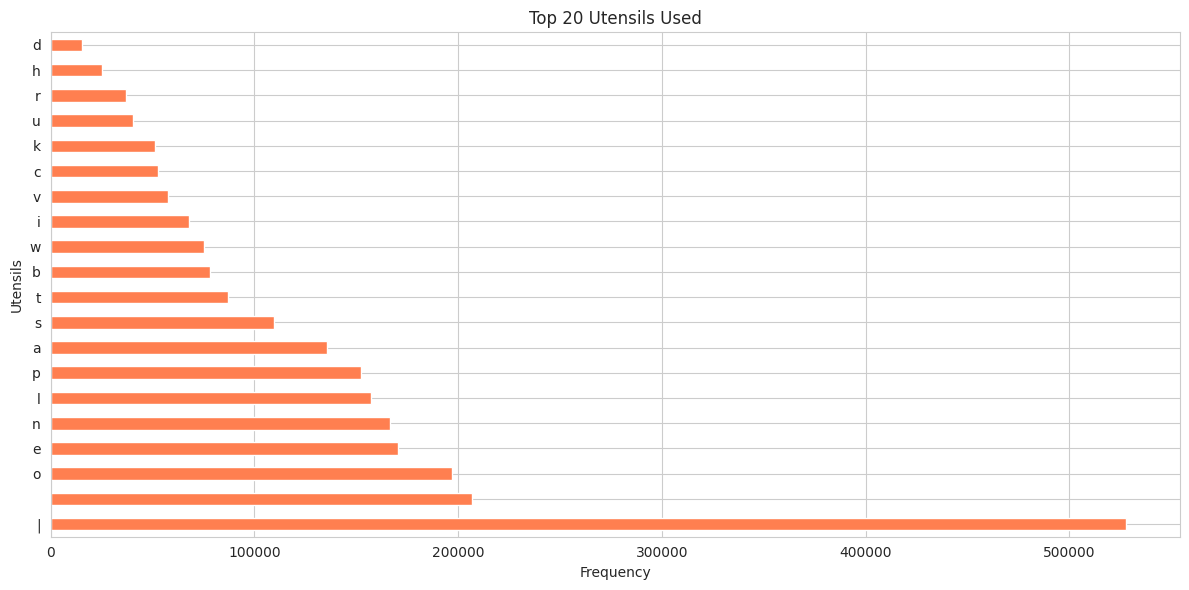

In [8]:
# Process analysis
print("\n=== Cooking Processes Analysis ===")
processes_list = df['Processes'].dropna().str.split('||').explode()
top_processes = processes_list.value_counts().head(20)
print(top_processes)

plt.figure(figsize=(12, 6))
top_processes.plot(kind='barh')
plt.xlabel('Frequency')
plt.title('Top 20 Cooking Processes')
plt.tight_layout()
plt.savefig('top_processes.png', dpi=300, bbox_inches='tight')
plt.show()

# Utensils analysis
print("\n=== Utensils Analysis ===")
utensils_list = df['Utensils'].dropna().str.split('||').explode()
top_utensils = utensils_list.value_counts().head(20)
print(top_utensils)

plt.figure(figsize=(12, 6))
top_utensils.plot(kind='barh', color='coral')
plt.xlabel('Frequency')
plt.title('Top 20 Utensils Used')
plt.tight_layout()
plt.savefig('top_utensils.png', dpi=300, bbox_inches='tight')
plt.show()



=== Average Nutrients by Top 10 Regions ===
                         Calories  Carbohydrate, by difference (g)  \
Region                                                               
Australian             481.240093                      2138.475056   
Canadian               450.776964                       265.788555   
Chinese and Mongolian  444.969548                       261.301054   
French                 508.449898                       630.525743   
Indian Subcontinent    405.327603                      1356.548630   
Italian                506.526729                       559.323250   
Mexican                408.834422                       225.140048   
South American         563.640692                       302.124039   
UK                     533.774340                      1623.455125   
US                     352.606567                       167.098763   

                       Energy (kcal)  Protein (g)  Total lipid (fat) (g)  
Region                                 

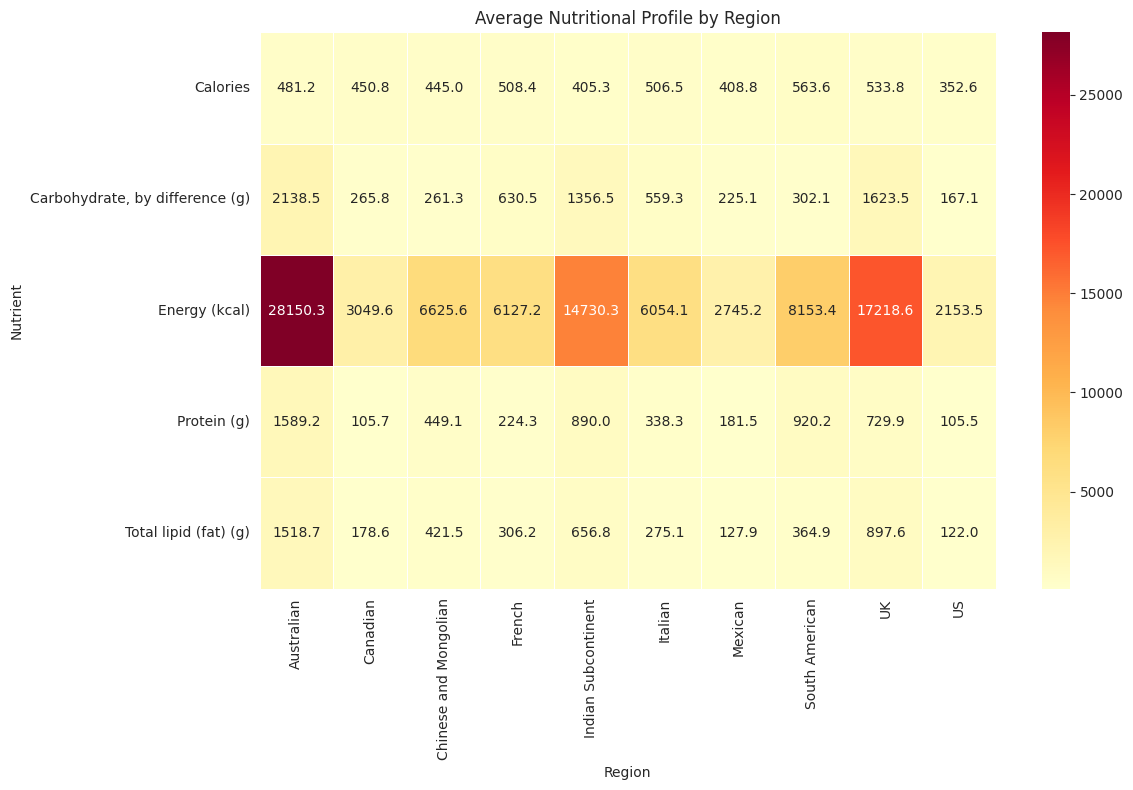

In [9]:
# Average nutrients by region (top 10 regions)
top_regions = df['Region'].value_counts().head(10).index
df_top_regions = df[df['Region'].isin(top_regions)]

region_nutrients = df_top_regions.groupby('Region')[nutrient_cols].mean()

print("\n=== Average Nutrients by Top 10 Regions ===")
print(region_nutrients)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(region_nutrients.T, annot=True, cmap='YlOrRd', fmt='.1f', linewidths=0.5)
plt.title('Average Nutritional Profile by Region')
plt.xlabel('Region')
plt.ylabel('Nutrient')
plt.tight_layout()
plt.savefig('region_nutrient_profile.png', dpi=300, bbox_inches='tight')
plt.show()



=== Servings Statistics ===
count    72052.000000
mean         7.049756
std          9.372816
min          1.000000
25%          4.000000
50%          6.000000
75%          8.000000
max       1000.000000
Name: servings_numeric, dtype: float64


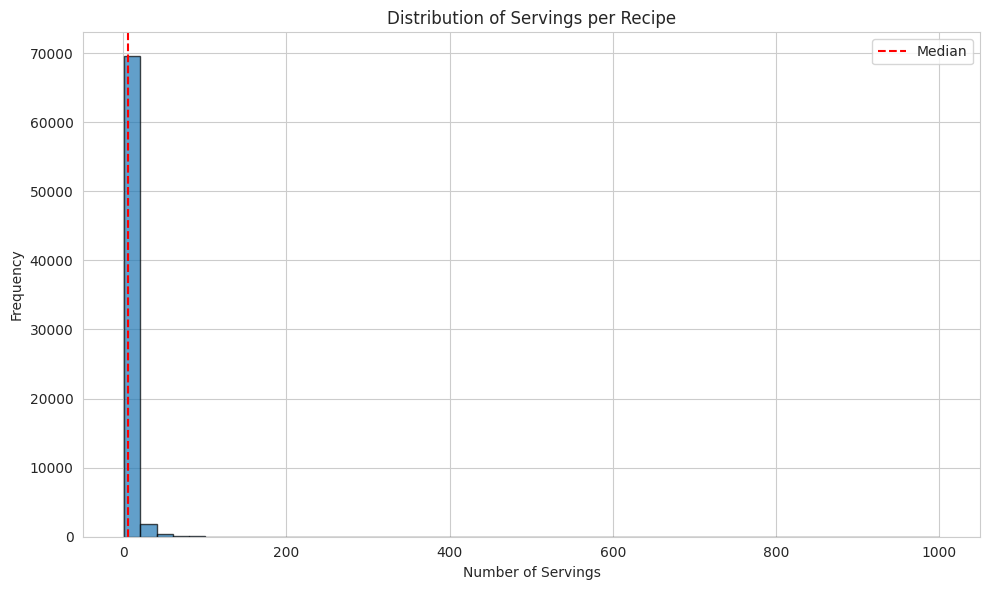

In [10]:
# Convert servings to numeric
df['servings_numeric'] = pd.to_numeric(df['servings'], errors='coerce')

print("\n=== Servings Statistics ===")
print(df['servings_numeric'].describe())

plt.figure(figsize=(10, 6))
df['servings_numeric'].dropna().hist(bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Servings')
plt.ylabel('Frequency')
plt.title('Distribution of Servings per Recipe')
plt.axvline(df['servings_numeric'].median(), color='red', linestyle='--', label='Median')
plt.legend()
plt.tight_layout()
plt.savefig('servings_distribution.png', dpi=300, bbox_inches='tight')
plt.show()



=== Macronutrient Ratio Statistics ===
       protein_to_carb_ratio  fat_to_protein_ratio  carb_to_fat_ratio
count          117039.000000         117039.000000      117039.000000
mean               14.478327              7.576502          29.384367
std               427.549651            660.741438        1343.617447
min                 0.000000              0.000000           0.000000
25%                 0.170849              0.337880           0.420209
50%                 0.453598              0.913442           1.333857
75%                 1.849098              2.246633           4.674105
max             75690.197300         218000.000000      179073.047375


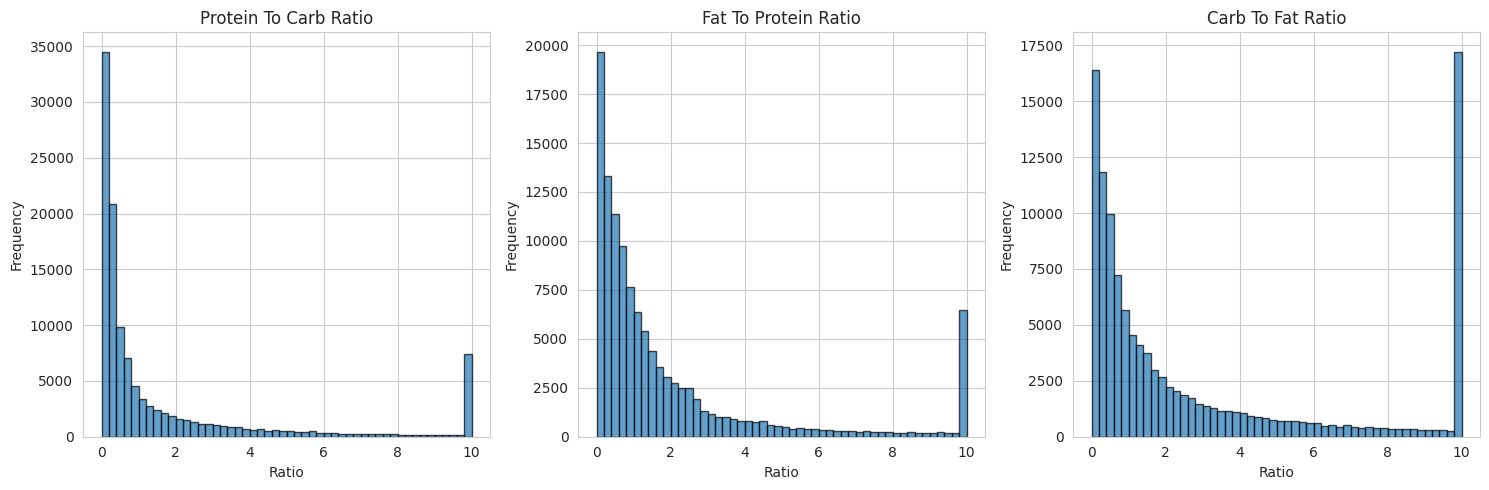

In [11]:
# Calculate macronutrient ratios
df['protein_to_carb_ratio'] = df['Protein (g)'] / (df['Carbohydrate, by difference (g)'] + 1)
df['fat_to_protein_ratio'] = df['Total lipid (fat) (g)'] / (df['Protein (g)'] + 1)
df['carb_to_fat_ratio'] = df['Carbohydrate, by difference (g)'] / (df['Total lipid (fat) (g)'] + 1)

print("\n=== Macronutrient Ratio Statistics ===")
ratio_cols = ['protein_to_carb_ratio', 'fat_to_protein_ratio', 'carb_to_fat_ratio']
print(df[ratio_cols].describe())

# Visualize ratios
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(ratio_cols):
    axes[idx].hist(df[col].dropna().clip(0, 10), bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col.replace("_", " ").title()}')
    axes[idx].set_xlabel('Ratio')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('nutrient_ratios.png', dpi=300, bbox_inches='tight')
plt.show()


In [12]:
# Detect outliers using IQR method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), (len(outliers) / len(df) * 100)

print("\n=== Outlier Analysis ===")
for col in nutrient_cols:
    outlier_count, outlier_pct = detect_outliers(df, col)
    print(f"{col}: {outlier_count} outliers ({outlier_pct:.2f}%)")



=== Outlier Analysis ===
Calories: 6578 outliers (5.57%)
Carbohydrate, by difference (g): 11332 outliers (9.60%)
Energy (kcal): 10605 outliers (8.98%)
Protein (g): 11239 outliers (9.52%)
Total lipid (fat) (g): 11111 outliers (9.41%)


In [13]:
# Create summary report
summary_report = {
    'Total Recipes': len(df),
    'Unique Regions': df['Region'].nunique(),
    'Unique Continents': df['Continent'].nunique(),
    'Average Calories': df['Calories'].mean(),
    'Average Protein (g)': df['Protein (g)'].mean(),
    'Average Carbs (g)': df['Carbohydrate, by difference (g)'].mean(),
    'Average Fat (g)': df['Total lipid (fat) (g)'].mean(),
    'Vegan Recipes': int(df['vegan'].sum()),
    'Pescetarian Recipes': int(df['pescetarian'].sum())
}

summary_df = pd.DataFrame(list(summary_report.items()), columns=['Metric', 'Value'])
print("\n=== Final Summary Report ===")
print(summary_df)

# Save summary
summary_df.to_csv('eda_summary_report.csv', index=False)
print("\nSummary report saved to 'eda_summary_report.csv'")



=== Final Summary Report ===
                Metric          Value
0        Total Recipes  118083.000000
1       Unique Regions      26.000000
2    Unique Continents       6.000000
3     Average Calories     473.770486
4  Average Protein (g)     509.474261
5    Average Carbs (g)     835.972820
6      Average Fat (g)     488.816511
7        Vegan Recipes   10643.000000
8  Pescetarian Recipes   13184.000000

Summary report saved to 'eda_summary_report.csv'
